In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import sys
sys.path.append('..')

In [2]:
from src.preprocessing import load_and_clean, engineer_features
df = load_and_clean('../data/bank_churn.csv')
df = engineer_features(df)

In [3]:
cluster_features = ['Age', 'Balance', 'CreditScore', 'Tenure', 'balance_salary_ratio']
X_cluster = df[cluster_features].copy()

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [6]:
#Elbow method to test the value of K from 2 to 10
inertias = []
for k in range(2,11):
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

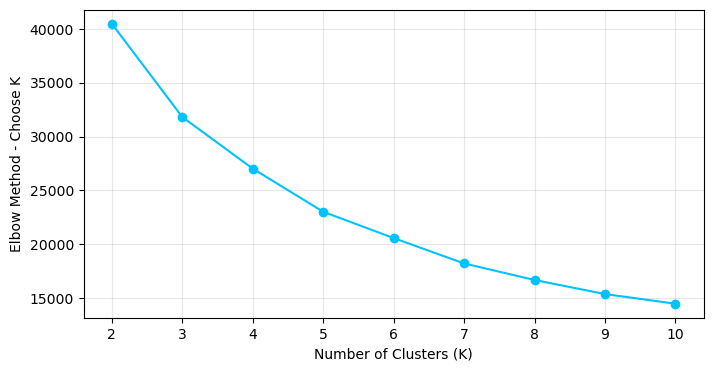

In [7]:
plt.figure(figsize = (8,4))
plt.plot(range(2,11), inertias, 'o-' , color = '#00C2FF')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Elbow Method - Choose K')
plt.grid(True, alpha = 0.3)
plt.show()

In [8]:
#applying k means with 4 clusters
kmeans = KMeans (n_clusters = 4, random_state = 42, n_init = 10)
df['segment'] = kmeans.fit_predict(X_scaled)

segment_profile = df.groupby('segment')[cluster_features + ['Exited']].mean()
print(segment_profile.round(2))

print('\nChurn rate per segment: ')
print(df.groupby('segment')['Exited'].mean().round(3))

           Age    Balance  CreditScore  Tenure  balance_salary_ratio  Exited
segment                                                                     
0        38.43    1486.85       649.30    5.07                  0.03    0.14
1        45.00  122917.71       709.00    4.00               9770.88    1.00
2        38.35  120488.17       648.88    2.53                  4.09    0.23
3        40.14  121677.79       653.77    7.59                  4.86    0.25

Churn rate per segment: 
segment
0    0.144
1    1.000
2    0.229
3    0.251
Name: Exited, dtype: float64


In [11]:
# Save segment assignments back to main dataframe
df.to_csv('../data/bank_churn_segmented.csv', index=False)